# Subtask 1 Statistics Analysis

This notebook analyzes the original Reddit posts and gold evidence spans in `train.xlsx`.

The cells follow the requested order, with an additional user-level analysis by `anon_user_id`:

1. Setup
2. Original post length at word level
3. Original post word length by category
4. Evidence word count and comparison with post length
5. Evidence word length distribution
6. User-level analysis by `anon_user_id`
7. Optional Subtask 2 note


## 1. Setup

Load the training data, normalize risk labels, and define helper functions for word counting and evidence splitting. Evidence placeholders such as `none` are treated as no evidence.


In [8]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("train.xlsx")
REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(exist_ok=True)

RISK_ORDER = ["Indicator", "Ideation", "Behavior", "Attempt"]
RISK_LABEL_MAP = {
    "indicator": "Indicator",
    "ideation": "Ideation",
    "behavior": "Behavior",
    "attempt": "Attempt",
}


def normalize_risk_label(value):
    key = str(value).strip().lower()
    return RISK_LABEL_MAP.get(key, np.nan)


NONE_EVIDENCE_VALUES = {"", "none", "nan", "na", "n/a", "null"}


def normalize_text_for_match(text):
    return re.sub(r"\s+", " ", str(text).lower()).strip()


def word_count(text):
    return len(re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", str(text)))


def split_raw_evidence_spans(value):
    if pd.isna(value):
        return []
    return [span.strip() for span in str(value).split(";") if span.strip()]


def is_none_evidence(span):
    return normalize_text_for_match(span) in NONE_EVIDENCE_VALUES


def split_evidence_spans(value):
    return [span for span in split_raw_evidence_spans(value) if not is_none_evidence(span)]


def add_whole_row(grouped_stats, whole_stats):
    whole = pd.DataFrame([whole_stats], index=["Whole"])
    return pd.concat([whole, grouped_stats.reindex(RISK_ORDER)])


df = pd.read_excel(DATA_PATH)
df = df.rename(
    columns={
        "suicide risk": "risk_level",
        "evidence for suicide risk level": "evidence",
    }
).copy()

df["risk_level"] = df["risk_level"].apply(normalize_risk_label)

if df["risk_level"].isna().any():
    bad_labels = df.loc[df["risk_level"].isna(), "risk_level"].unique()
    raise ValueError(f"Found invalid risk labels after normalization: {bad_labels}")

df["post"] = df["post"].fillna("")
df["raw_evidence_spans"] = df["evidence"].apply(split_raw_evidence_spans)
df["evidence_spans"] = df["evidence"].apply(split_evidence_spans)
df["none_evidence_count"] = df["raw_evidence_spans"].apply(lambda spans: sum(is_none_evidence(span) for span in spans))

print(f"Loaded {len(df):,} training rows")
display(df["risk_level"].value_counts().reindex(RISK_ORDER).to_frame("post_count"))
display(df.head(3))

Loaded 1,635 training rows


,post_count
risk_level,
Indicator,611
Ideation,519
Behavior,391
Attempt,114


,row_id,anon_user_id,post_id,post,risk_level,evidence,factors,raw_evidence_spans,evidence_spans,none_evidence_count
0,P00000,U0122,0,"My thoughts are getting worse. Already am suffering from severe depression due to past events over the months, final...",Ideation,just wanna die; just wanna fucking die,"['mental health issues', 'stressful life event', 'coping strategy', 'emotion dysregulation', 'traumatic experience',...","[just wanna die, just wanna fucking die]","[just wanna die, just wanna fucking die]",0
1,P00001,U0122,1,"I'm done with this healing and everything.. I'm done..I tried a lot. I cannot do this anymore. I'm going to die, goo...",Ideation,going to die,"['hopelessness', 'hopelessness', 'coping strategy', 'hopelessness']",[going to die],[going to die],0
2,P00002,U0122,2,"Tired. 12:34am at night. 6% charge on my phone. World is quiet, world is dark. I just want to pass away in my sleep....",Ideation,pass away in my sleep; do not want to wake up; want to die peacefully; wish to not see tomorrow; wish to die; kill m...,"['hopelessness', 'hopelessness']","[pass away in my sleep, do not want to wake up, want to die peacefully, wish to not see tomorrow, wish to die, kill ...","[pass away in my sleep, do not want to wake up, want to die peacefully, wish to not see tomorrow, wish to die, kill ...",0


## 2. Analyze Sentence/Post Length: Word Level

This section counts words in each original post, then reports the average post length for the whole dataset and for each risk level.

In [9]:
df["post_word_count"] = df["post"].apply(word_count)

post_word_grouped = df.groupby("risk_level")["post_word_count"].agg(
    post_count="count",
    average_post_words="mean",
    median_post_words="median",
    min_post_words="min",
    max_post_words="max",
)

post_word_whole = df["post_word_count"].agg(
    post_count="count",
    average_post_words="mean",
    median_post_words="median",
    min_post_words="min",
    max_post_words="max",
)

post_word_stats = add_whole_row(post_word_grouped, post_word_whole).round(2)
post_word_stats.to_csv(REPORT_DIR / "post_word_length_stats.csv")

display(post_word_stats)

,post_count,average_post_words,median_post_words,min_post_words,max_post_words
Whole,1635.0,70.01,38.0,0.0,2071.0
Indicator,611.0,47.43,21.0,0.0,1260.0
Ideation,519.0,74.61,46.0,3.0,1483.0
Behavior,391.0,84.34,45.0,3.0,2071.0
Attempt,114.0,120.85,81.5,3.0,1415.0


## 3. Analyze Sentence/Post Length: Word Level by Category

This section visualizes and compares post word counts across `Indicator`, `Ideation`, `Behavior`, and `Attempt`.

,post_count,average_post_words,median_post_words,min_post_words,max_post_words
Whole,1635.0,70.01,38.0,0.0,2071.0
Indicator,611.0,47.43,21.0,0.0,1260.0
Ideation,519.0,74.61,46.0,3.0,1483.0
Behavior,391.0,84.34,45.0,3.0,2071.0
Attempt,114.0,120.85,81.5,3.0,1415.0


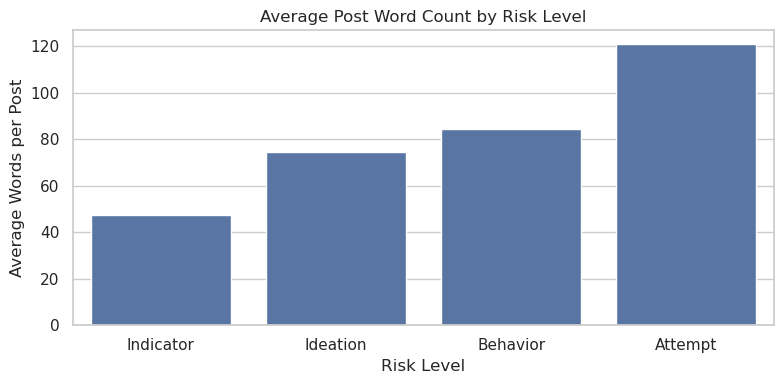

In [10]:
display(post_word_stats)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=post_word_stats.drop(index="Whole").reset_index(names="risk_level"),
    x="risk_level",
    y="average_post_words",
    order=RISK_ORDER,
)
plt.title("Average Post Word Count by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Words per Post")
plt.tight_layout()
plt.show()

## 4. Evidence Word Count and Comparison with Post Length

This section counts words in the gold evidence text for each post, then compares average evidence word count with average post word count for the whole dataset and each risk level. Placeholder values such as `none` are counted as zero evidence words.


In [11]:
df["evidence_word_count"] = df["evidence_spans"].apply(lambda spans: sum(word_count(span) for span in spans))
df["evidence_span_count"] = df["evidence_spans"].apply(len)
df["raw_evidence_span_count"] = df["raw_evidence_spans"].apply(len)

evidence_word_grouped = df.groupby("risk_level")["evidence_word_count"].agg(
    post_count="count",
    average_evidence_words="mean",
    median_evidence_words="median",
    min_evidence_words="min",
    max_evidence_words="max",
)

evidence_word_whole = df["evidence_word_count"].agg(
    post_count="count",
    average_evidence_words="mean",
    median_evidence_words="median",
    min_evidence_words="min",
    max_evidence_words="max",
)

evidence_word_stats = add_whole_row(evidence_word_grouped, evidence_word_whole).round(2)
evidence_word_stats.to_csv(REPORT_DIR / "evidence_word_count_stats.csv")

post_vs_evidence_stats = post_word_stats[["average_post_words"]].join(
    evidence_word_stats[["average_evidence_words"]]
)
post_vs_evidence_stats["evidence_words_as_percent_of_post"] = (
    post_vs_evidence_stats["average_evidence_words"]
    / post_vs_evidence_stats["average_post_words"]
    * 100
)
post_vs_evidence_stats = post_vs_evidence_stats.round(2)
post_vs_evidence_stats.to_csv(REPORT_DIR / "post_vs_evidence_word_count_stats.csv")

evidence_quality_grouped = df.groupby("risk_level")[[
    "raw_evidence_span_count",
    "none_evidence_count",
    "evidence_span_count",
]].sum()
evidence_quality_whole = df[[
    "raw_evidence_span_count",
    "none_evidence_count",
    "evidence_span_count",
]].sum()
evidence_quality_stats = add_whole_row(evidence_quality_grouped, evidence_quality_whole)
evidence_quality_stats["none_evidence_percent"] = (
    evidence_quality_stats["none_evidence_count"]
    / evidence_quality_stats["raw_evidence_span_count"].replace(0, np.nan)
    * 100
).fillna(0)
evidence_quality_stats = evidence_quality_stats.round(2)
evidence_quality_stats.to_csv(REPORT_DIR / "evidence_cleaning_quality_stats.csv")

print("Evidence word statistics after removing placeholder evidence values like 'none':")
display(evidence_word_stats)
print("Average post words compared with average evidence words:")
display(post_vs_evidence_stats)
print("Evidence cleaning quality check:")
display(evidence_quality_stats)


Evidence word statistics after removing placeholder evidence values like 'none':


,post_count,average_evidence_words,median_evidence_words,min_evidence_words,max_evidence_words
Whole,1635.0,8.75,8.0,0.0,43.0
Indicator,611.0,4.48,8.0,0.0,30.0
Ideation,519.0,10.43,10.0,1.0,43.0
Behavior,391.0,12.43,11.0,1.0,43.0
Attempt,114.0,11.38,9.0,1.0,40.0


Average post words compared with average evidence words:


,average_post_words,average_evidence_words,evidence_words_as_percent_of_post
Whole,70.01,8.75,12.50
Indicator,47.43,4.48,9.45
Ideation,74.61,10.43,13.98
Behavior,84.34,12.43,14.74
Attempt,120.85,11.38,9.42


Evidence cleaning quality check:


,raw_evidence_span_count,none_evidence_count,evidence_span_count,none_evidence_percent
Whole,2421,280,2141,11.57
Indicator,630,280,350,44.44
Ideation,885,0,885,0.00
Behavior,705,0,705,0.00
Attempt,201,0,201,0.00


## 5. Evidence Word Length Distribution

This section computes word length for every real evidence phrase, excluding placeholder values such as `none`, then reports the distribution for the whole dataset and each risk level.


In [12]:
evidence_rows = []

for _, row in df.iterrows():
    post_for_match = normalize_text_for_match(row["post"])
    for span in row["evidence_spans"]:
        span_for_match = normalize_text_for_match(span)
        evidence_rows.append(
            {
                "row_id": row["row_id"],
                "risk_level": row["risk_level"],
                "evidence_span": span,
                "evidence_word_length": word_count(span),
                "exact_substring_in_post": span_for_match in post_for_match,
            }
        )

evidence_df = pd.DataFrame(evidence_rows)

def distribution_stats(series):
    return pd.Series(
        {
            "evidence_span_count": series.count(),
            "mean": series.mean(),
            "median": series.median(),
            "min": series.min(),
            "max": series.max(),
            "p25": series.quantile(0.25),
            "p75": series.quantile(0.75),
            "p90": series.quantile(0.90),
        }
    )


if evidence_df.empty:
    evidence_length_stats = pd.DataFrame()
else:
    evidence_length_grouped = evidence_df.groupby("risk_level")["evidence_word_length"].apply(distribution_stats).unstack()
    evidence_length_whole = distribution_stats(evidence_df["evidence_word_length"])
    evidence_length_stats = add_whole_row(evidence_length_grouped, evidence_length_whole).round(2)

    exact_match_grouped = evidence_df.groupby("risk_level")["exact_substring_in_post"].agg(
        real_evidence_span_count="count",
        exact_substring_count="sum",
        exact_substring_percent="mean",
    )
    exact_match_whole = evidence_df["exact_substring_in_post"].agg(
        real_evidence_span_count="count",
        exact_substring_count="sum",
        exact_substring_percent="mean",
    )
    exact_match_stats = add_whole_row(exact_match_grouped, exact_match_whole)
    exact_match_stats["exact_substring_percent"] *= 100
    exact_match_stats = exact_match_stats.round(2)

    evidence_length_stats.to_csv(REPORT_DIR / "evidence_word_length_distribution_stats.csv")
    exact_match_stats.to_csv(REPORT_DIR / "evidence_exact_substring_quality_stats.csv")

    print("Evidence word-length distribution after removing placeholder evidence values like 'none':")
    display(evidence_length_stats)
    print("Exact-substring quality check for real evidence phrases:")
    display(exact_match_stats)
    display(evidence_df.head(10))


Evidence word-length distribution after removing placeholder evidence values like 'none':


,evidence_span_count,mean,median,min,max,p25,p75,p90
Whole,2141.0,6.68,6.0,1.0,23.0,3.0,9.0,12.0
Indicator,350.0,7.82,8.0,1.0,17.0,8.0,8.0,8.0
Ideation,885.0,6.12,5.0,1.0,19.0,3.0,9.0,12.0
Behavior,705.0,6.89,6.0,1.0,23.0,3.0,10.0,13.0
Attempt,201.0,6.45,6.0,1.0,18.0,4.0,9.0,12.0


Exact-substring quality check for real evidence phrases:


,real_evidence_span_count,exact_substring_count,exact_substring_percent
Whole,2141.0,1223.0,57.12
Indicator,350.0,24.0,6.86
Ideation,885.0,586.0,66.21
Behavior,705.0,466.0,66.10
Attempt,201.0,147.0,73.13


,row_id,risk_level,evidence_span,evidence_word_length,exact_substring_in_post
0,P00000,Ideation,just wanna die,3,True
1,P00000,Ideation,just wanna fucking die,4,True
2,P00001,Ideation,going to die,3,True
3,P00002,Ideation,pass away in my sleep,5,True
4,P00002,Ideation,do not want to wake up,6,True
5,P00002,Ideation,want to die peacefully,4,True
6,P00002,Ideation,wish to not see tomorrow,5,True
7,P00002,Ideation,wish to die,3,True
8,P00002,Ideation,kill myself,2,True
9,P00002,Ideation,hope I die,3,True


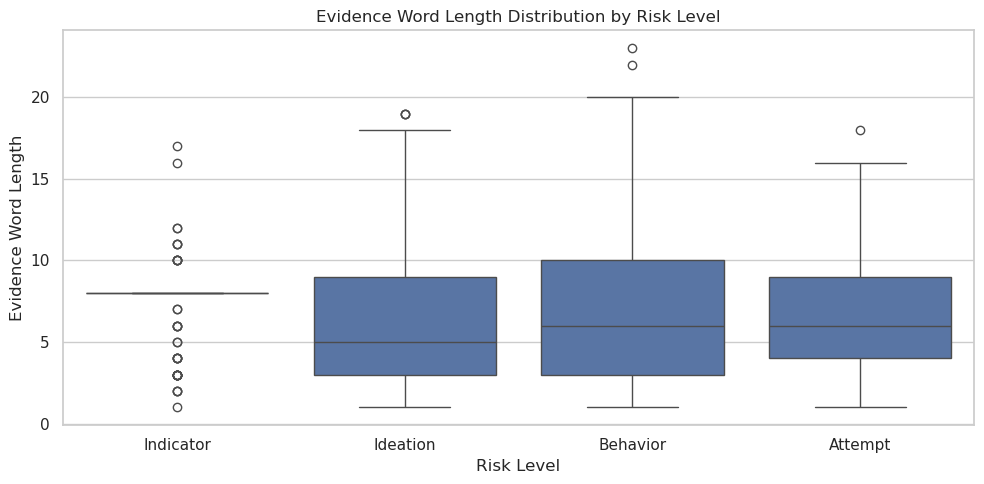

In [13]:
if evidence_df.empty:
    print("No real evidence phrases to plot.")
else:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=evidence_df,
        x="risk_level",
        y="evidence_word_length",
        order=RISK_ORDER,
    )
    plt.title("Evidence Word Length Distribution by Risk Level")
    plt.xlabel("Risk Level")
    plt.ylabel("Evidence Word Length")
    plt.tight_layout()
    plt.show()


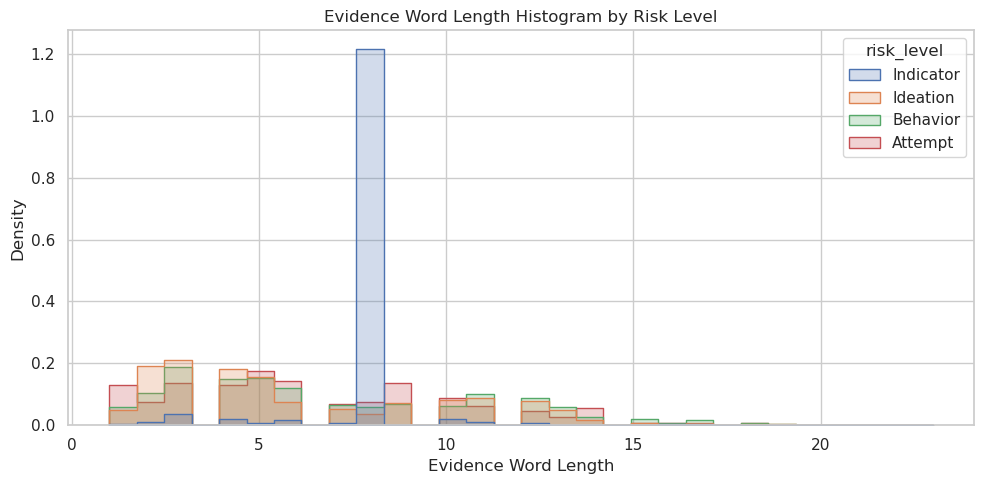

In [14]:
if evidence_df.empty:
    print("No real evidence phrases to plot.")
else:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=evidence_df,
        x="evidence_word_length",
        hue="risk_level",
        hue_order=RISK_ORDER,
        bins=30,
        element="step",
        stat="density",
        common_norm=False,
    )
    plt.title("Evidence Word Length Histogram by Risk Level")
    plt.xlabel("Evidence Word Length")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()


## 6. User-Level Analysis by `anon_user_id`

This section groups posts by anonymous user. It helps show how many posts each user contributes, whether users appear in multiple risk categories, and why validation should be split by user instead of by random post.


In [15]:
risk_rank = {"Indicator": 0, "Ideation": 1, "Behavior": 2, "Attempt": 3}
risk_rank_to_label = {value: key for key, value in risk_rank.items()}

user_summary = df.groupby("anon_user_id").agg(
    post_count=("row_id", "count"),
    average_post_words=("post_word_count", "mean"),
    total_post_words=("post_word_count", "sum"),
    average_evidence_words_per_post=("evidence_word_count", "mean"),
    total_evidence_words=("evidence_word_count", "sum"),
    total_real_evidence_phrases=("evidence_span_count", "sum"),
    unique_risk_levels=("risk_level", "nunique"),
)

user_risk_counts = pd.crosstab(df["anon_user_id"], df["risk_level"]).reindex(columns=RISK_ORDER, fill_value=0)
user_summary = user_summary.join(user_risk_counts)
user_summary["dominant_risk_level"] = user_risk_counts.idxmax(axis=1)
user_summary["highest_risk_level"] = (
    df.assign(risk_rank=df["risk_level"].map(risk_rank))
    .groupby("anon_user_id")["risk_rank"]
    .max()
    .map(risk_rank_to_label)
)
user_summary = user_summary.round(2)
user_summary.to_csv(REPORT_DIR / "user_level_summary_stats.csv")

user_overall_stats = user_summary[[
    "post_count",
    "average_post_words",
    "average_evidence_words_per_post",
    "total_real_evidence_phrases",
    "unique_risk_levels",
]].agg(["count", "mean", "median", "min", "max"]).round(2)
user_overall_stats.to_csv(REPORT_DIR / "user_level_overall_stats.csv")

print("Overall user-level statistics:")
display(user_overall_stats)
print("One row per anon_user_id:")
display(user_summary.head(10))


Overall user-level statistics:


,post_count,average_post_words,average_evidence_words_per_post,total_real_evidence_phrases,unique_risk_levels
count,153.00,153.00,153.00,153.00,153.00
mean,10.69,75.12,9.08,13.99,2.79
median,9.00,56.78,9.62,12.00,3.00
min,7.00,5.88,0.25,1.00,1.00
max,30.00,570.86,21.14,56.00,4.00


One row per anon_user_id:


,post_count,average_post_words,total_post_words,average_evidence_words_per_post,total_evidence_words,total_real_evidence_phrases,unique_risk_levels,Indicator,Ideation,Behavior,Attempt,dominant_risk_level,highest_risk_level
anon_user_id,,,,,,,,,,,,,
U0002,14,66.79,935,6.57,92,14,4,4,6,2,2,Ideation,Attempt
U0003,8,26.50,212,1.50,12,3,2,5,3,0,0,Indicator,Ideation
U0005,12,41.50,498,2.42,29,6,3,7,4,1,0,Indicator,Behavior
U0006,13,168.85,2195,4.46,58,12,4,6,4,2,1,Indicator,Attempt
U0008,28,8.89,249,0.86,24,9,3,19,8,1,0,Indicator,Behavior
U0009,11,112.73,1240,5.55,61,16,3,1,7,3,0,Ideation,Behavior
U0011,7,30.00,210,1.71,12,3,2,4,3,0,0,Indicator,Ideation
U0013,12,30.42,365,3.50,42,9,3,5,5,2,0,Indicator,Behavior
U0014,19,44.95,854,1.79,34,9,3,11,6,0,2,Indicator,Attempt


In [16]:
risk_diversity_stats = user_summary["unique_risk_levels"].value_counts().sort_index().rename_axis(
    "unique_risk_levels_per_user"
).to_frame("user_count")
risk_diversity_stats["user_percent"] = (risk_diversity_stats["user_count"] / len(user_summary) * 100).round(2)
risk_diversity_stats.to_csv(REPORT_DIR / "user_level_risk_diversity_stats.csv")

dominant_risk_stats = user_summary["dominant_risk_level"].value_counts().reindex(RISK_ORDER, fill_value=0).to_frame("user_count")
dominant_risk_stats["user_percent"] = (dominant_risk_stats["user_count"] / len(user_summary) * 100).round(2)
dominant_risk_stats.to_csv(REPORT_DIR / "user_level_dominant_risk_stats.csv")

highest_risk_stats = user_summary["highest_risk_level"].value_counts().reindex(RISK_ORDER, fill_value=0).to_frame("user_count")
highest_risk_stats["user_percent"] = (highest_risk_stats["user_count"] / len(user_summary) * 100).round(2)
highest_risk_stats.to_csv(REPORT_DIR / "user_level_highest_risk_stats.csv")

print("How many different risk levels each user has:")
display(risk_diversity_stats)
print("Dominant risk level per user:")
display(dominant_risk_stats)
print("Highest observed risk level per user:")
display(highest_risk_stats)


How many different risk levels each user has:


,user_count,user_percent
unique_risk_levels_per_user,,
1,7,4.58
2,42,27.45
3,80,52.29
4,24,15.69


Dominant risk level per user:


,user_count,user_percent
dominant_risk_level,,
Indicator,64,41.83
Ideation,49,32.03
Behavior,32,20.92
Attempt,8,5.23


Highest observed risk level per user:


,user_count,user_percent
highest_risk_level,,
Indicator,3,1.96
Ideation,28,18.30
Behavior,79,51.63
Attempt,43,28.10


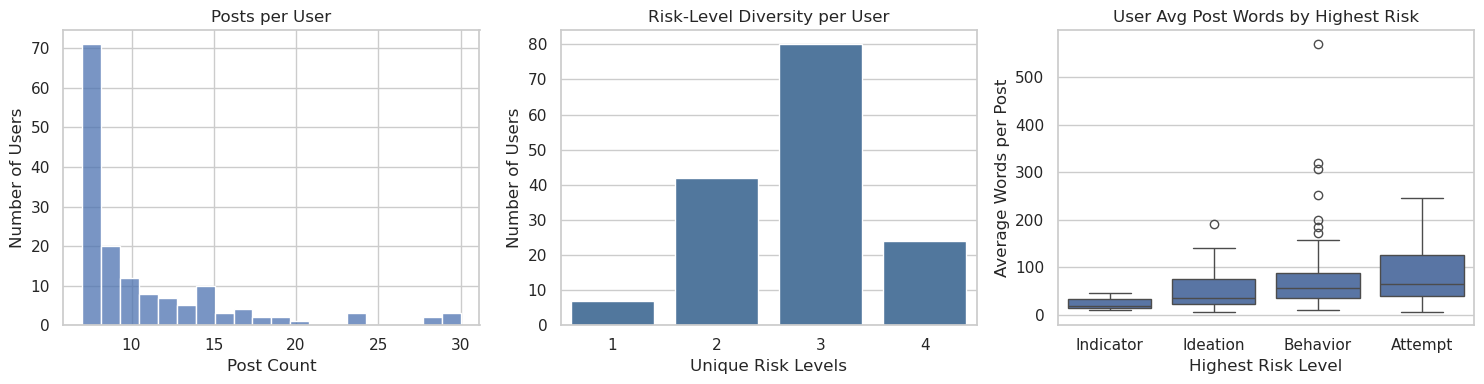

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(user_summary["post_count"], bins=20, ax=axes[0])
axes[0].set_title("Posts per User")
axes[0].set_xlabel("Post Count")
axes[0].set_ylabel("Number of Users")

sns.countplot(
    data=user_summary.reset_index(),
    x="unique_risk_levels",
    ax=axes[1],
    color="#4477AA",
)
axes[1].set_title("Risk-Level Diversity per User")
axes[1].set_xlabel("Unique Risk Levels")
axes[1].set_ylabel("Number of Users")

sns.boxplot(
    data=user_summary.reset_index(),
    x="highest_risk_level",
    y="average_post_words",
    order=RISK_ORDER,
    ax=axes[2],
)
axes[2].set_title("User Avg Post Words by Highest Risk")
axes[2].set_xlabel("Highest Risk Level")
axes[2].set_ylabel("Average Words per Post")

plt.tight_layout()
plt.show()


In [18]:
user_risk_sequences = (
    df.sort_values(["anon_user_id", "post_id"])
    .groupby("anon_user_id")["risk_level"]
    .apply(lambda labels: " -> ".join(labels))
    .to_frame("risk_sequence_by_post_id")
)
user_risk_sequences["post_count"] = user_summary["post_count"]
user_risk_sequences["unique_risk_levels"] = user_summary["unique_risk_levels"]
user_risk_sequences.to_csv(REPORT_DIR / "user_level_risk_sequences.csv")

print("Example user risk sequences ordered by post_id:")
display(user_risk_sequences.sort_values(["unique_risk_levels", "post_count"], ascending=False).head(10))


Example user risk sequences ordered by post_id:


,risk_sequence_by_post_id,post_count,unique_risk_levels
anon_user_id,,,
U0146,Behavior -> Attempt -> Attempt -> Behavior -> Attempt -> Behavior -> Attempt -> Behavior -> Behavior -> Attempt -> A...,30,4
U0092,Ideation -> Behavior -> Indicator -> Behavior -> Behavior -> Ideation -> Behavior -> Behavior -> Behavior -> Behavio...,28,4
U0019,Behavior -> Behavior -> Behavior -> Behavior -> Behavior -> Behavior -> Behavior -> Indicator -> Attempt -> Behavior...,18,4
U0115,Ideation -> Behavior -> Indicator -> Ideation -> Indicator -> Indicator -> Attempt -> Indicator -> Attempt -> Attemp...,17,4
U0175,Ideation -> Ideation -> Behavior -> Behavior -> Indicator -> Indicator -> Attempt -> Attempt -> Indicator -> Ideatio...,17,4
U0179,Attempt -> Attempt -> Ideation -> Indicator -> Ideation -> Ideation -> Ideation -> Behavior -> Attempt -> Indicator ...,16,4
U0147,Behavior -> Indicator -> Indicator -> Ideation -> Attempt -> Behavior -> Ideation -> Behavior -> Indicator -> Indica...,15,4
U0206,Indicator -> Ideation -> Behavior -> Indicator -> Ideation -> Attempt -> Ideation -> Ideation -> Behavior -> Ideatio...,15,4
U0002,Indicator -> Ideation -> Ideation -> Indicator -> Ideation -> Attempt -> Indicator -> Behavior -> Indicator -> Behav...,14,4


## 7. Optional: Subtask 2 Labels Statistics

Skipped in this notebook version.

If added later, this section should analyze factor-label frequencies, the average number of unique factor labels per post, factor distribution by risk level, and optionally train a simple multi-label TF-IDF baseline classifier.